# Exercise 3: Hazard classification from exceedance probabilities — Antigua and Barbuda

Four rasters, each giving the probability that flooding reaches a particular depth,
produced by the UFFIS/TITO forecast chain for the Tropical Storm Jerry hindcast
(October 2025). This notebook combines them into a single hazard classification and
then works out which buildings and roads fall inside each level — the same
computation the Antigua and Barbuda dashboard plugins run.

The question being answered is:

> **What are the odds of at least 30 cm of water here?**

Exercise 2 sampled *depth* from one storm of the flood-map library. This works from
**exceedance probabilities** across the 50 members of a forecast, which is the product
a forecaster actually issues.

**What to take away from it**

- how four nested probability layers collapse into one classification, and why the
  rule assigns levels in ascending order
- why a threshold is a modelling decision rather than a detail, and how to check what
  range the data can actually reach before exposing one
- how to verify an upstream classification (`hazard_flag`) against your own rule
  instead of taking it on trust
- why the parish, not the pixel, is the unit a warning is issued for

**Workflow**

1. Read the four probability rasters and check they share a grid
2. Classify pixels into hazard levels with the escalating-gate rule
3. Sweep a gate to see what the data can reach
4. Classify the buildings and roads directly from the probabilities they carry
5. Verify the IBF workflow's own `hazard_flag`
6. Build the impact table, overall and by parish
7. Map it

Everything is read from a public S3 bucket. Nothing needs to be downloaded first.

In [1]:
import sys

# Google Colab ships geopandas but not rasterio or pyogrio. A local environment
# made with `pip install -e .` from the plugin repo already has everything.
if "google.colab" in sys.modules:
    %pip install -q rasterio pyogrio

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.colors import BoundaryNorm, ListedColormap

%matplotlib inline

In [3]:
BUCKET = "https://cog-s3-test-401506828094-us-east-1-an.s3.us-east-1.amazonaws.com"

# P(maximum depth >= threshold) for the four IBF depth thresholds, shallowest first.
# "overbank" means the water that stays inside the channel in every scenario has
# been removed, so what is left is flooding that reaches the streets.
PROB = {
    "10cm":  f"{BUCKET}/antigua_barbuda_IBF/depth_prob/antiguabarbuda_prob_depth_ge_10cm_overbank.tif",
    "30cm":  f"{BUCKET}/antigua_barbuda_IBF/depth_prob/antiguabarbuda_prob_depth_ge_30cm_overbank.tif",
    "70cm":  f"{BUCKET}/antigua_barbuda_IBF/depth_prob/antiguabarbuda_prob_depth_ge_70cm_overbank.tif",
    "100cm": f"{BUCKET}/antigua_barbuda_IBF/depth_prob/antiguabarbuda_prob_depth_ge_100cm_overbank.tif",
}
ORDER = list(PROB)                                   # shallowest to deepest

# Buildings, roads, places and parish summaries of the IBF run, in one geopackage.
FEATURES = f"{BUCKET}/antigua_barbuda_IBF/AntiguaBarbuda_Jerry_cycle_10151010_IBF_outputs.gpkg"

print("ready")

ready


## 1. The four probability rasters

Each raster holds **P(maximum flood depth ≥ threshold)** for one depth. The forecast
that produced them had 50 members — five StormLab rainfall realizations run from each
of ten satellite-rainfall analysis states — and each member's rainfall total selects
the closest scenario from a library of 200 synthetic storms (the library Exercise 2
reads). A cell value of 0.30 in the 30 cm raster therefore means *"15 of the 50
members put at least 30 cm of water here"*.

Two consequences follow from that construction, and both show up below:

- probabilities move in steps of **1/50 = 0.02**, and take few distinct values,
  because five rainfall fields drive most of the spread
- a footprint shared by every matched scenario reaches probability **1.0**, so the
  top level is reachable — unlike the Guatemala data, where the deepest layer never
  exceeds 0.2

The rasters are EPSG:4326 at one arc-second (about 30 m), covering both islands.

In [4]:
layers, meta = {}, {}
for name, url in PROB.items():
    with rasterio.open(url) as ds:
        layers[name] = ds.read(1, masked=True)
        meta[name] = {"crs": ds.crs, "shape": ds.shape, "transform": ds.transform,
                      "res_deg": ds.res[0], "nodata": ds.nodata}

for name, m in meta.items():
    valid = layers[name].compressed()
    print(f"P(>= {name:>5})  {m['crs']}  {m['shape']}  {m['res_deg'] * 3600:.0f} arc-second  "
          f"{(valid > 0).sum():>7,} cells above zero  {len(np.unique(valid)):>3} distinct values  "
          f"max {valid.max():.2f}")

shapes_seen = {v.shape for v in layers.values()}
print(f"\nall four share one grid: {len(shapes_seen) == 1}")

P(>=  10cm)  EPSG:4326  (2658, 921)  1 arc-second   40,861 cells above zero   44 distinct values  max 1.00
P(>=  30cm)  EPSG:4326  (2658, 921)  1 arc-second   14,801 cells above zero   44 distinct values  max 1.00
P(>=  70cm)  EPSG:4326  (2658, 921)  1 arc-second    2,972 cells above zero   37 distinct values  max 1.00
P(>= 100cm)  EPSG:4326  (2658, 921)  1 arc-second      786 cells above zero   30 distinct values  max 1.00

all four share one grid: True


## 2. The classification rule

Each hazard level is tied to **one** depth layer, and each has its own probability
gate. The gates below are the defaults the dashboard plugins ship with; the IBF
workflow that produced the geopackage used a single gate for every level (section 5
works out which).

| level | driven by | plugin default gate |
|---|---|---|
| Low | P(≥ 10 cm) | 0.30 |
| Medium | P(≥ 30 cm) | 0.20 |
| High | P(≥ 70 cm) | 0.10 |
| Severe | P(≥ 100 cm) | 0.15 |

A pixel takes the level of the **deepest** threshold whose gate it clears. That falls
out of assigning the levels in ascending order and letting later assignments win.
The gates are not monotonic, and they do not need to be: a deeper threshold is rarer,
so a lower gate on it says *"take a one-in-ten chance of 70 cm as seriously as a
one-in-three chance of ankle depth"*.

This is the same `clasificar_peligro` the plugins call, ported from the UFFIS notebook.

         cells
level         
Normal  954516
Low      13514
Medium    9463
High      2238
Severe     713


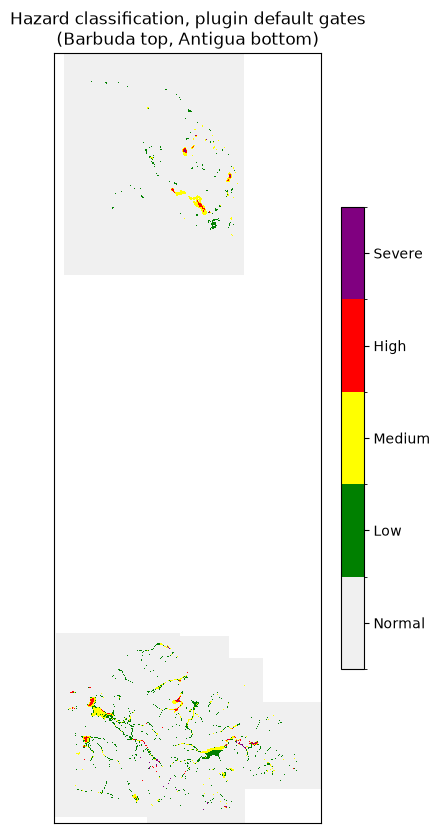

In [5]:
LEVELS = [(1, "green"), (2, "yellow"), (3, "red"), (4, "purple")]
LEVEL_LABEL = {0: "Normal", 1: "Low", 2: "Medium", 3: "High", 4: "Severe"}
NODATA = 255

LOW_THRESHOLD = 0.30       # gate on P(>= 10 cm)
MEDIUM_THRESHOLD = 0.20    # gate on P(>= 30 cm)
HIGH_THRESHOLD = 0.10      # gate on P(>= 70 cm)
SEVERE_THRESHOLD = 0.15    # gate on P(>= 100 cm)
GATES = {1: LOW_THRESHOLD, 2: MEDIUM_THRESHOLD, 3: HIGH_THRESHOLD, 4: SEVERE_THRESHOLD}


def clasificar_peligro(layers, gates):
    """0 = Normal, 1..4 = hazard level, 255 = NoData."""
    first = layers[ORDER[0]]
    # A pixel missing from any layer cannot be classified at all.
    invalid = np.zeros(first.shape, dtype=bool)
    for name in ORDER:
        invalid |= np.ma.getmaskarray(layers[name])

    hazard = np.zeros(first.shape, dtype=np.uint8)
    # Ascending order: each assignment overwrites the last, so the deepest
    # threshold a pixel clears is the one that sticks.
    for name, (value, _colour) in zip(ORDER, LEVELS):
        hazard[layers[name].filled(-np.inf) >= gates[value]] = value

    hazard[invalid] = NODATA
    return hazard


hazard = clasificar_peligro(layers, GATES)

counts = pd.Series(hazard[hazard != NODATA]).value_counts().sort_index()
print(counts.rename(LEVEL_LABEL).rename_axis("level").to_frame("cells").to_string())

cmap = ListedColormap(["#f0f0f0", "green", "yellow", "red", "purple"])
norm = BoundaryNorm([0, 1, 2, 3, 4, 5], cmap.N)

fig, ax = plt.subplots(figsize=(5, 10))
drawn = np.where(hazard == NODATA, np.nan, hazard)
im = ax.imshow(drawn, cmap=cmap, norm=norm, interpolation="nearest")
ax.set_title("Hazard classification, plugin default gates\n(Barbuda top, Antigua bottom)")
ax.set_xticks([]); ax.set_yticks([])
cbar = fig.colorbar(im, ax=ax, ticks=[0.5, 1.5, 2.5, 3.5, 4.5], shrink=0.6)
cbar.ax.set_yticklabels([LEVEL_LABEL[v] for v in range(5)])
plt.show()

## 3. What a gate can and cannot do

Before exposing a threshold as a dashboard control, look at what the data can reach.
Sweep one common gate across every level and watch the cell counts: with
probabilities in steps of 0.02 and few distinct values, the counts move in plateaus,
and a level empties the moment its gate passes the layer's maximum. Here every layer
reaches 1.0, so every level survives up to the last step — the Guatemala data loses
its Severe level at 0.2.

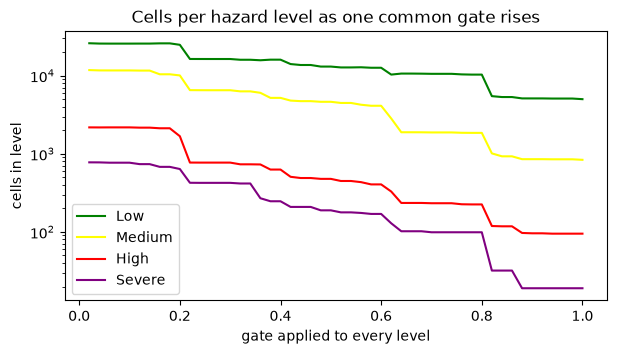

,Low,Medium,High,Severe
gate,,,,
0.1,25785,11691,2181,770
0.2,24889,10090,1681,639
0.3,16376,6521,772,425
0.4,16061,5206,629,247
0.5,13103,4637,478,189
0.8,10340,1855,225,99
1.0,5012,838,95,19


In [6]:
sweep = np.round(np.arange(0.02, 1.001, 0.02), 2)
rows = []
for gate in sweep:
    trial = clasificar_peligro(layers, {1: gate, 2: gate, 3: gate, 4: gate})
    valid = trial[trial != NODATA]
    rows.append({"gate": gate, **{LEVEL_LABEL[v]: int((valid == v).sum()) for v, _c in LEVELS}})
sweep_df = pd.DataFrame(rows).set_index("gate")

fig, ax = plt.subplots(figsize=(7, 3.5))
for value, colour in LEVELS:
    ax.plot(sweep_df.index, sweep_df[LEVEL_LABEL[value]], color=colour, lw=1.5, label=LEVEL_LABEL[value])
ax.set_yscale("log")
ax.set_xlabel("gate applied to every level"); ax.set_ylabel("cells in level")
ax.set_title("Cells per hazard level as one common gate rises")
ax.legend(); plt.show()

sweep_df.loc[[0.1, 0.2, 0.3, 0.4, 0.5, 0.8, 1.0]]

## 4. Classifying the buildings and roads

Each building and road in the IBF geopackage **already carries the four
probabilities**, sampled as the maximum over its own footprint, so the same gates
classify a feature directly with no rasterising involved.

The geopackage has four layers — buildings, roads, places and a parish summary — and
two things about it need handling on load:

- the buildings layer stores its severe-depth probability under the name
  **`probability_30cm`**. It is P(≥ 100 cm), misnamed upstream; the roads layer calls
  the same field `probability_severe`. It is renamed on load, exactly as the plugin does.
- **`population_per_building`** is a parish population estimate spread over the
  residential buildings by built-up area, not a census count. **`wrldpp_sum`**, sitting
  next to it, repeats the *whole parish total* on every building — summing that one
  overstates exposure by four orders of magnitude. Always check whether a population
  field is a total or a disaggregation.

Reading a 27 MB geopackage straight off HTTPS goes through GDAL's `/vsicurl`, which
range-requests the file once per layer; downloading it once is much faster.

In [7]:
import tempfile
import urllib.request
from pathlib import Path

import pyogrio

PROB_FIELDS = ["probability_low", "probability_med", "probability_high", "probability_severe"]
MEASURES = ["population_per_building", "building_area_m2", "road_length_m"]

# type -> (layer, renames)
AB_LAYERS = {
    "building": ("AntiguaBarbuda_Jerry_cycle_10151010_bldgs", {"probability_30cm": "probability_severe"}),
    "road": ("AntiguaBarbuda_Jerry_cycle_10151010_roads", {}),
}


def cached(url):
    """Fetch once into the temp dir and return the local path."""
    path = Path(tempfile.gettempdir()) / url.rsplit("/", 1)[-1]
    if not path.exists():
        urllib.request.urlretrieve(url, path)
    return path


def read_features(read_geometry=False):
    """Buildings and roads stacked into one frame with a `type` column."""
    source = cached(FEATURES)
    parts = []
    for type_, (layer, renames) in AB_LAYERS.items():
        available = set(pyogrio.read_info(source, layer=layer)["fields"])
        wanted = [f for f in PROB_FIELDS if f not in renames.values()] + list(renames)
        wanted += ["GID_1", "hazard_flag"] + MEASURES
        part = pyogrio.read_dataframe(source, layer=layer,
                                      columns=[f for f in wanted if f in available],
                                      read_geometry=read_geometry, use_arrow=True)
        part = part.rename(columns=renames)
        part["type"] = type_
        parts.append(part)
    if read_geometry:
        stacked = gpd.GeoDataFrame(pd.concat(parts, ignore_index=True), crs=parts[0].crs)
    else:
        stacked = pd.concat(parts, ignore_index=True)
    # A road has no population and a building no length: fill so every row sums.
    for col in MEASURES:
        stacked[col] = stacked[col].fillna(0.0) if col in stacked else 0.0
    return stacked


features = read_features()
print(f"{len(features):,} features")
print(features["type"].value_counts().to_string())
print()
features[["type", "GID_1"] + PROB_FIELDS].head(3)

80,451 features
type
building    71136
road         9315



,type,GID_1,probability_low,probability_med,probability_high,probability_severe
0,building,ATG.5_1,0.0,0.0,0.0,0.0
1,building,ATG.5_1,0.0,0.0,0.0,0.0
2,building,ATG.5_1,0.0,0.0,0.0,0.0


In [8]:
def classify_features(df, gates):
    hazard = pd.Series(0, index=df.index, dtype="uint8")
    for field, (value, _colour) in zip(PROB_FIELDS, LEVELS):
        hazard[df[field] >= gates[value]] = value      # deepest gate cleared wins
    return hazard


features["hazard"] = classify_features(features, GATES)
features["level"] = features.hazard.map(LEVEL_LABEL)
pd.crosstab(features["level"], features["type"]).reindex([LEVEL_LABEL[v] for v in range(5)])

type,building,road
level,,
Normal,68536,8669
Low,2135,485
Medium,421,135
High,30,18
Severe,14,8


## 5. Verifying the workflow's own `hazard_flag`

The geopackage carries a `hazard_flag` column written by the IBF workflow. The
workshop data package describes it as *"the highest depth threshold whose probability
is at least 0.5"*. The workflow script that wrote the geopackage says
`hazard_prob_threshold = 0.4`. Both cannot be right — so instead of choosing, test:
apply our rule with one common gate, sweep it, and see which value reproduces the
column exactly.

The lesson generalises. Whenever a dataset arrives with a classification already in
it, that classification is a claim about how it was made. Recover the method from the
data before building on it.

In [9]:
match = {}
for gate in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    trial = classify_features(features, {1: gate, 2: gate, 3: gate, 4: gate})
    match[gate] = (trial == features.hazard_flag).mean()

report = pd.Series(match, name="share of features matching hazard_flag").rename_axis("common gate")
print(report.map("{:.4%}".format).to_string())

common gate
0.30     99.5364%
0.35     99.8633%
0.40    100.0000%
0.45     99.6793%
0.50     99.5637%
0.55     99.4108%
0.60     99.2853%


## 6. The impact table

Deepest level first; Normal is left out because it is everything the gates did not
catch, so it carries no exposure. The population share is against every building in
the geopackage — the two islands together.

Antigua and Barbuda issues warnings by **parish**, so the second table breaks the same
exposure down by parish, each against its own population. The parish names and
populations come from the geopackage's own summary layer.

In [10]:
TOTAL_POPULATION = features.population_per_building.sum()      # every building, both islands
print(f"population across all buildings: {TOTAL_POPULATION:,.0f}")


def impact_row(name, group, total_population=TOTAL_POPULATION):
    buildings = group[group["type"] == "building"]
    return {
        "Level": name,
        "Buildings": f"{len(buildings):,}",
        "Population": f"{group.population_per_building.sum():,.0f}",
        "Area (m²)": f"{group.building_area_m2.sum():,.0f}",
        "Roads (km)": f"{group.road_length_m.sum() / 1000:,.1f}",
        "% of population": f"{100 * group.population_per_building.sum() / total_population:.2f}%",
    }


at_risk = features[features.hazard > 0]
table = [impact_row(LEVEL_LABEL[v], at_risk[at_risk.hazard == v]) for v, _c in reversed(LEVELS)]
table.append(impact_row("TOTAL at risk", at_risk))
pd.DataFrame(table).set_index("Level")

population across all buildings: 93,839


,Buildings,Population,Area (m²),Roads (km),% of population
Level,,,,,
Severe,14,7,671,9.4,0.01%
High,30,36,"3,681",5.4,0.04%
Medium,421,458,"41,132",42.3,0.49%
Low,"2,135","2,595","202,445",102.9,2.77%
TOTAL at risk,"2,600","3,097","247,930",160.0,3.30%


In [11]:
parishes = pyogrio.read_dataframe(cached(FEATURES), layer="AntiguaBarbuda_Jerry_cycle_10151010_admin_summary",
                                  read_geometry=True, use_arrow=True)
parish_name = parishes.set_index("GID_1").NAME_1
parish_pop = parishes.set_index("GID_1").total_pop

rows = []
for gid, group in at_risk.groupby("GID_1"):
    row = impact_row(parish_name[gid], group, total_population=parish_pop[gid])
    row["Worst level"] = LEVEL_LABEL[int(group.hazard.max())]
    rows.append(row)
by_parish = pd.DataFrame(rows).rename(columns={"Level": "Parish", "% of population": "% of parish population"})
by_parish.set_index("Parish").sort_values(
    "Buildings", key=lambda s: s.str.replace(",", "").astype(int), ascending=False)

,Buildings,Population,Area (m²),Roads (km),% of parish population,Worst level
Parish,,,,,,
Saint John,"1,410","1,863","126,505",49.6,3.31%,High
Saint Mary,480,523,"48,594",25.8,6.41%,Severe
Saint George,210,196,"26,670",22.1,2.20%,Severe
Saint Peter,195,241,"18,969",15.9,4.12%,Severe
Saint Paul,139,173,"14,026",14.7,1.91%,Severe
Saint Philip,105,68,"9,530",23.3,1.81%,Severe
Barbuda,61,32,"3,637",8.6,1.86%,Medium


## 7. Mapping it

The classified grid with the buildings and roads at risk on top, zoomed to Saint
John's parish, where most of the exposure is.

Both layers have to be in the *same* CRS to overlay: the features are stored in UTM
zone 20N (EPSG:32620) and the rasters are EPSG:4326, so the features are reprojected
onto the raster's grid before anything is drawn — cheap, because it is vector data.

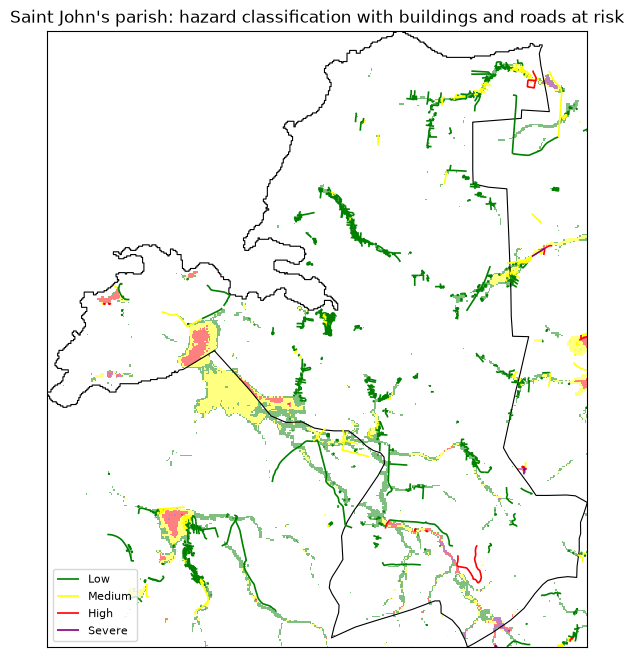

In [12]:
from rasterio.transform import array_bounds

geo = read_features(read_geometry=True)
geo["hazard"] = classify_features(geo, GATES)

grid_crs = meta[ORDER[0]]["crs"]
grid_rows, grid_cols = meta[ORDER[0]]["shape"]
left, bottom, right, top = array_bounds(grid_rows, grid_cols, meta[ORDER[0]]["transform"])

# Same CRS or the two layers will not line up.
geo_grid = geo.to_crs(grid_crs)
saint_johns = parishes.to_crs(grid_crs)[parishes.NAME_1 == "Saint John"].geometry.iloc[0]
xmin, ymin, xmax, ymax = saint_johns.bounds

fig, ax = plt.subplots(figsize=(9, 8))
# Normal and NoData left transparent so the classified areas read clearly.
shaded = np.where((hazard > 0) & (hazard != NODATA), hazard, np.nan).astype("float32")
ax.imshow(shaded, cmap=cmap, norm=norm, interpolation="nearest",
          extent=(left, right, bottom, top), alpha=0.5)
gpd.GeoSeries([saint_johns], crs=grid_crs).boundary.plot(ax=ax, color="black", linewidth=0.8)

for value, colour in LEVELS:
    subset = geo_grid[geo_grid.hazard == value]
    if not subset.empty:
        subset.plot(ax=ax, color=colour, linewidth=1.2, edgecolor=colour, label=LEVEL_LABEL[value])

ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_title("Saint John's parish: hazard classification with buildings and roads at risk")
ax.set_xticks([]); ax.set_yticks([])
handles, labels = ax.get_legend_handles_labels()        # polygons and lines share a label
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc="lower left", fontsize=8)
plt.show()

## 8. How the dashboard plugins do it

Everything above runs here, in a notebook. To put it on a dashboard the same code has
to become a **plugin**: an installable Python package that TethysDash finds on its own.
The computation does not change — what follows is only the wrapper, and the contracts
that wrapper has to satisfy.

### Discovery — how the app finds it

A plugin is a class registered as an **Intake entry point** in its package's
`pyproject.toml`. The Antigua and Barbuda variants are three entries:

```toml
[project.entry-points."intake.drivers"]
uffis_impact_summary_antigua_barbuda = "tgf_wmo_plugins.impact_summary:ImpactSummaryAntiguaBarbuda"
uffis_impact_layer_antigua_barbuda   = "tgf_wmo_plugins.impact_layer:ImpactLayerAntiguaBarbuda"
uffis_hazard_layer_antigua_barbuda   = "tgf_wmo_plugins.hazard_layer:HazardLayerAntiguaBarbuda"
```

Once the package is installed next to TethysDash (`pip install -e .` and a server
restart), the three plugins appear in the visualization picker under
*Flood Maps (English)*.

### One country is a subclass

Each plugin family has one base class that holds the computation, and one subclass
per country and language that sets only what differs. The hazard layer's base fills
in `label`, `args`, `tags` and `description` from `LANG` and `country` the moment a
subclass is defined, so the whole Antigua and Barbuda variant is:

```python
class HazardLayerAntiguaBarbuda(BaseHazardLayer):
    LANG = "en"
    country = "antigua_barbuda"
    name = "uffis_hazard_layer_antigua_barbuda"
    label = f"{STRINGS['en']['hazard_layer_label']} (Antigua and Barbuda)"
```

`country` selects the data and `LANG` selects the strings. The data tables are
exactly what this notebook hard-coded in sections 1 and 4:

```python
PROB_URLS["antigua_barbuda"]          # the four rasters, shallowest first   (classification.py)
PROB_FIELDS["antigua_barbuda"]        # probability_low ... probability_severe  (common.py)
GPKG_LAYERS["antigua_barbuda"]        # the two layers and the probability_30cm rename  (common.py)
TOTAL_POPULATION["antigua_barbuda"]   # 93,839 -- the denominator of "% of population"
```

### The class — discovery properties, args, and one method

```python
from tethysapp.tethysdash.plugin_helpers import TethysDashPlugin


class ImpactSummaryAntiguaBarbuda(BaseImpactSummary):

    # ---- discovery: how the GUI lists and presents this plugin -----------
    LANG = "en"
    country = "antigua_barbuda"
    name = "uffis_impact_summary_antigua_barbuda"   # must match the entry-point key
    label = "Flood Impact Summary (Antigua and Barbuda)"
    group = "Flood Maps (English)"                 # the heading it is filed under
    description = "People, buildings and roads in each flood hazard level, ..."
    tags = ["flood", "impact", "IBF", "exposure", "table", "english"]

    # ---- what the GUI asks the dashboard author to fill in ---------------
    args = {
        "low_threshold":    "number",    # gate on P(>= 10 cm)
        "medium_threshold": "number",    # gate on P(>= 30 cm)
        "high_threshold":   "number",    # gate on P(>= 70 cm)
        "severe_threshold": "number",    # gate on P(>= 100 cm)
    }
    # "number" renders a numeric input; a list of {"value", "label"} would
    # render a dropdown instead. The GUI derives each field's label from the
    # arg name, so `low_threshold` displays as "Low Threshold".


# ... and in the base class every country shares:

type = "table"
# `type` picks the frontend renderer, and therefore dictates the shape run()
# must return. One of: table, card, plotly, image, text, variable_input,
# map, map_layer, custom.

def run(self):
    """Called once per request, and again whenever a bound arg changes."""
    gates = self.gates()
    # gates() calls get_arg() once per threshold. If the author bound that
    # arg to a variable input, the "${Low Threshold ...}" reference is
    # already resolved by now -- the plugin never sees the template syntax.

    df = _load(csv_url, self.country)                  # section 4: the two layers, stacked
    df["hazard"] = 0
    for field, (value, _color) in zip(PROB_FIELDS[country], LEVELS):
        df.loc[df[field] >= gates[value], "hazard"] = value   # section 4, unchanged

    # A `table` returns a title and a list of row dicts. Keys become the
    # columns in order; values are preformatted strings, because how a
    # number should read is a decision the renderer cannot make.
    return {"title": "Impact by hazard level",
            "data": [{"Level": "...", "Buildings": "...", "Population": "..."}]}
```

### Args are part of the public contract

Argument *names* are the keys a dashboard stores, which makes them a published
interface rather than an implementation detail. The English plugins expose
`low_threshold` … `severe_threshold`; the Spanish and French variants declare
`umbral_bajo` … and `seuil_faible` … instead.

Two consequences worth understanding, because both are silent failures:

- An argument a plugin does **not** declare is simply absent at run time — it does
  not raise. Pass `umbral_bajo` to an English plugin and every gate quietly falls back
  to its default, so the dashboard loads fine and the controls appear to do nothing.
- Renaming an argument breaks every dashboard already bound to the old name, in
  exactly that silent way. Choose the names before publishing.

Internally the gates are keyed by **class value**, never by name:

```python
THRESHOLD_ARGS = {
    "en": {1: "low_threshold", 2: "medium_threshold", 3: "high_threshold", 4: "severe_threshold"},
    "es": {1: "umbral_bajo", 2: "umbral_medio", 3: "umbral_alto", 4: "umbral_severo"},
    "fr": {1: "seuil_faible", 2: "seuil_moyen", 3: "seuil_eleve", 4: "seuil_severe"},
}
DEFAULT_GATES = {1: 0.3, 2: 0.2, 3: 0.1, 4: 0.15}      # the GATES of section 2


def gates(self):
    """-> {1: 0.3, 2: 0.2, 3: 0.1, 4: 0.15} -- keyed by hazard class value."""
    names = THRESHOLD_ARGS[self.LANG]
    # get_arg() per name, coerced to float, falling back to the default
    # when a threshold is unset or unparseable.
    return {value: self._gate(names[value], DEFAULT_GATES[value]) for value in sorted(DEFAULT_GATES)}
```

`gates[1]` rather than `gates["Low"]` is the point: one implementation serves every
country and language, and a translation can never reach the classification.

### Map layers implement two methods, not one

A `map_layer` plugin is asked two different questions at two different times, so it
answers them separately:

```python
class BaseHazardLayer(ThresholdGates, TethysDashPlugin):
    type = "map_layer"
    dynamic_map_layer = True     # this flag is what enables fetch_features()

    def run(self):
        """CONFIGURE time. Called once, when the author adds the layer.

        Returns the layer's *scaffold*, not its data: a name, a source binding,
        style rules and a legend. This is what the layer editor's
        "Fetch plugin defaults" button calls.
        """
        builder = LayerConfigurationBuilder("Hazard classification", "GeoJSON")

        builder.set_plugin_source(self.name, self.received_args)
        # received_args, NOT self.args. self.args is the *schema*; the runtime
        # re-invocation needs the configured *values*, including the
        # "${Low Threshold ...}" bindings that still have to be resolved on
        # each fetch.

        builder.set_style(...)    # four rules keyed on the `peligro` attribute
        builder.set_legend(...)   # what the map legend shows for this layer
        return builder.build()    # -> the layer configuration dict

    def fetch_features(self):
        """RUN time. Called on load, and again every time a bound gate changes.

        Returns GeoJSON. This is the only part that re-executes.
        """
        gates = self.gates()

        self.send_update("Reading probability layers...", percentage_complete=10)
        # send_update() streams progress to the tile over a WebSocket, so a
        # recompute that takes a few seconds looks busy rather than broken.
        layers, transform, crs = self._read(PROB_URLS[self.country])

        self.send_update("Classifying hazard...", percentage_complete=50)
        peligro = clasificar_peligro(*layers, gates)   # section 2, unchanged

        self.send_update("Building polygons...", percentage_complete=75)
        # A map layer can only point at a URL and nothing here serves a computed
        # raster, so the classified grid is vectorised: each connected run of
        # equal class becomes one polygon -- about 3,400 for Antigua and Barbuda
        # at the default gates. Normal and NoData are dropped: they are most of
        # the grid, and nothing a basemap does not already show.
        features = self._vectorize(...)

        return {"type": "FeatureCollection", "features": features,
                "crs": {"type": "name", "properties": {"name": str(crs)}}}
```

The rasters are EPSG:4326, which OpenLayers resolves without any projection library,
so they are served in that CRS as-is. The features are UTM 20N and are reprojected to
EPSG:4326 once, then cached — only the gates change between requests.

### The three plugins built on this data

| plugin | `type` | what it returns |
|---|---|---|
| `uffis_impact_summary_antigua_barbuda` | `table` | `{"title", "data": [row dicts]}` — the table from section 6 |
| `uffis_hazard_layer_antigua_barbuda` | `map_layer` | scaffold from `run()`; the classified grid, vectorised, from `fetch_features()` |
| `uffis_impact_layer_antigua_barbuda` | `map_layer` | scaffold from `run()`; the classified features from section 4 |

### Why the two-method split earns its keep

`run()` fires once, when someone is configuring the dashboard. `fetch_features()`
fires on every change to a bound threshold. Putting the style and legend in `run()`
means they are computed once and stored with the dashboard, so moving a threshold
re-runs only the part that actually depends on it.

Two more things the plugins do that section 4 did by hand: the geopackage is
downloaded once into the temp directory and shared by all three plugins (a
half-written file makes GDAL report *"database disk image is malformed"*, so the
download lands on a staging name and is moved into place only when complete), and
only the columns the plugin reads are pulled off disk.

### Things to try

- Set all four gates in section 2 to the value section 5 recovered and re-run
  sections 4 to 7. You have reproduced the IBF workflow's `hazard_flag`; does the map
  become easier to explain than the plugin defaults?
- Push the Severe gate to 1.0. The class survives here, unlike in Guatemala — but how
  many buildings are left in it, and would you issue a warning on them?
- Section 6 divides by the population of both islands; the parish table divides by
  each parish. Which denominator would a parish disaster coordinator want, and which
  would the national office want?
- Exercise 2 answered *"how deep in storm 150"*, this one *"what are the odds of
  30 cm"*. Both use the same buildings on the same grid. Which would you put in front
  of the NODS duty officer, and what would you say about the other?